# Hierarchical topic–aspect reranking on SciREx (English)

Этот notebook демонстрирует полный экспериментальный цикл:

1. загрузку и аудит англоязычного SciREx;
2. leakage-safe train/dev/test split;
3. построение train-only topic hierarchy;
4. анализ centroid, representative terms и soft routing;
5. настройку routing/mixing только на dev;
6. сравнение `baseline`, прежнего `static-keywords` и `hierarchical-static-keywords`;
7. QA quality, fallback/harm/win, Evidence Recall proxy и compute ratios;
8. сохранение versioned artifact и диагностик.

Extractive QA остаётся reader-механизмом. Topic label и gold/reference на inference не передаются.

In [1]:
from __future__ import annotations

import ast
import json
import sys
import time
from dataclasses import asdict, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / "untie").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Run the notebook from inside the UnTIE repository")
sys.path.insert(0, str(PROJECT_ROOT))

from untie.attention import AttentionKeywordExtractor
from untie.cli import load_static_keywords
from untie.config import PipelineConfig
from untie.extraction_metrics import char_f1
from untie.keyword_evidence import (
    EvidenceStore,
    ExtractionMetricCache,
    build_evidence_fingerprint,
    collect_document_evidence,
)
from untie.keyword_training import MetricWeights, StrategyConfig, TrainingConfig
from untie.keyword_tuning import ObjectiveConfig, deterministic_document_split
from untie.models import ModelFactory, profile_for_language
from untie.pipelines import (
    AnswerPipeline,
    DocumentProcessor,
    HierarchicalTopicRerankingPipeline,
    StaticKeywordRerankingPipeline,
)
from untie.topic_keyword_training import tune_topic_keyword_profiles
from untie.topics import (
    TopicBuildConfig,
    TopicDocument,
    TopicMixingConfig,
    TopicRoutingConfig,
    build_topic_artifact,
    document_topic_representation,
    load_topic_artifact,
    save_topic_artifact_atomic,
    save_topic_diagnostics,
    tune_topic_configuration,
)

# Управление стоимостью эксперимента.
QUICK_MODE = False
TRAIN_LIMIT = 80 if QUICK_MODE else None
DEV_LIMIT = 4 if QUICK_MODE else None
TEST_LIMIT = 6 if QUICK_MODE else None
LEAF_CLUSTERS = 4 if QUICK_MODE else 10
SEED = 42
DEVICE = "auto"  # замените на "cpu" для принудительного CPU

DATASET_PATH = PROJECT_ROOT / "datasets" / "scirex_structured.json"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "hierarchical_topic_notebook" / "en"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_colwidth", 140)
print(f"Project: {PROJECT_ROOT}")
print(f"Dataset exists: {DATASET_PATH.exists()}")
print(f"Quick mode: {QUICK_MODE}")

Project: /home/aiserver/POLINA/UnTIE_project
Dataset exists: True
Quick mode: False


## 1. Загрузка и аудит SciREx

Нормализуем разные исторические варианты полей датасета. Gold используется только для dev tuning и финальной test-оценки — не для topic representation или routing.

In [2]:
def parse_references(value) -> list[str]:
    if isinstance(value, list):
        values = value
    elif value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    else:
        try:
            parsed = ast.literal_eval(str(value))
            values = parsed if isinstance(parsed, (list, tuple)) else [parsed]
        except (SyntaxError, ValueError):
            values = [value]
    return [str(item).replace("_", " ").strip() for item in values if str(item).strip()]

def load_dataset_payload(path: Path):
    text = path.read_text(encoding="utf-8")
    try:
        payload = json.loads(text)
    except json.JSONDecodeError:
        payload = [json.loads(line) for line in text.splitlines() if line.strip()]
    if isinstance(payload, dict):
        payload = payload.get("documents", payload)
    if not isinstance(payload, list):
        raise ValueError("dataset must be a JSON array or JSONL records")
    return payload

payload = load_dataset_payload(DATASET_PATH)
df = pd.DataFrame(payload)
text_column = "original_text" if "original_text" in df else "text"
reference_column = "tasks_cleaned" if "tasks_cleaned" in df else "tasks"
id_column = "doc_id" if "doc_id" in df else "id"

dataset = pd.DataFrame({
    "doc_id": df[id_column].astype(str),
    "text": df[text_column].fillna("").astype(str),
    "references": df[reference_column].apply(parse_references),
})
for optional in ("title", "abstract", "headings"):
    dataset[optional] = df[optional] if optional in df else ("" if optional != "headings" else [[] for _ in range(len(df))])
dataset = dataset[dataset["text"].str.strip().ne("") & dataset["references"].map(bool)].reset_index(drop=True)

audit = pd.DataFrame({
    "documents": [len(dataset)],
    "median_chars": [int(dataset.text.str.len().median())],
    "median_references": [float(dataset.references.map(len).median())],
    "explicit_titles": [int(dataset.title.astype(str).str.strip().ne("").sum())],
    "explicit_abstracts": [int(dataset.abstract.astype(str).str.strip().ne("").sum())],
})
display(audit)
display(dataset[["doc_id", "text", "references"]].head(3))

,documents,median_chars,median_references,explicit_titles,explicit_abstracts
0,306,29645,1.0,0,0


,doc_id,text,references
0,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semantic Segmentation in Street Scenes section: Abstract Semantic image segmentation is an essen...,"[Semantic Segmentation, Real-Time Semantic Segmentation]"
1,0012de6bec1f25599e4f02517637e531a71909b9,document: V - Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation Convolutional Neural Networks (CNNs) ha...,[Volumetric Medical Image Segmentation]
2,007ab5528b3bd310a80d553cccad4b78dc496b02,"document: Bi - Directional Attention Flow for Machine Comprehension Machine comprehension (MC), answering a query about a given context ...","[Question Answering, Open-Domain Question Answering]"


## 2. Leakage-safe split и topic representation

Centroid, hierarchy и vocabulary строятся только по train. Dev выбирает параметры. Test остаётся финальной однократной оценкой.

In [3]:
split = deterministic_document_split(dataset.doc_id, seed=SEED)
split_sets = {name: set(ids) for name, ids in split.items()}
assert split_sets["train"].isdisjoint(split_sets["dev"] | split_sets["test"])
assert split_sets["dev"].isdisjoint(split_sets["test"])

def rows_for(name: str, limit: int | None) -> pd.DataFrame:
    result = dataset[dataset.doc_id.isin(split_sets[name])].copy().sort_values("doc_id")
    return result.iloc[:limit].copy() if limit else result

train_frame = rows_for("train", TRAIN_LIMIT)
dev_frame = rows_for("dev", DEV_LIMIT)
test_frame = rows_for("test", TEST_LIMIT)

def make_topic_documents(frame: pd.DataFrame, split_name: str) -> list[TopicDocument]:
    documents = []
    for row in frame.itertuples():
        headings = row.headings if isinstance(row.headings, list) else []
        documents.append(TopicDocument(
            doc_id=row.doc_id,
            text=row.text,
            title=str(row.title) if pd.notna(row.title) else "",
            abstract=str(row.abstract) if pd.notna(row.abstract) else "",
            headings=tuple(str(item) for item in headings),
            split=split_name,
        ))
    return documents

train_docs = make_topic_documents(train_frame, "train")
dev_docs = make_topic_documents(dev_frame, "dev")
test_docs = make_topic_documents(test_frame, "test")

display(pd.DataFrame({"split": ["train", "dev", "test"], "used": [len(train_docs), len(dev_docs), len(test_docs)], "available": [len(split["train"]), len(split["dev"]), len(split["test"])]}))
example_repr = document_topic_representation(train_docs[0])
display(Markdown("**Пример topic representation:**\n\n```text\n" + example_repr[:1200] + "\n```"))

,split,used,available
0,train,183,183
1,dev,61,61
2,test,62,62


**Пример topic representation:**

```text
Full - Resolution Residual Networks for Semantic Segmentation in Street Scenes section: Abstract Semantic image segmentation is an essential component of modern autonomous driving systems, as an accurate understanding of the surrounding scene is crucial to navigation and action planning. Current state - of - the - art approaches in semantic image segmentation rely on pretrained networks that were initially developed for classifying images as a whole. While these networks exhibit outstanding recognition performance (i.e., what is visible?), they lack localization accuracy (i.e., where precisely is something located?). Therefore, additional processing steps have to be performed in order to obtain pixel - accurate segmentation masks at the full image resolution. To alleviate this problem we propose a novel ResNet - like architecture that exhibits strong localization and recognition performance. We combine multi - scale context with pixel - level accuracy by using two processing streams within our network: One stream carries information at the full image resolution, enabling precise adherence to segment boundaries. The other stream undergoes a sequence of pooling operations to obtain r
```

## 3. Модели и прежний static-keywords artifact

Загружается существующий sentence encoder и extractive QA. Никакой causal/generative модели нет. Первый запуск может быть долгим, если локальные веса ещё не подготовлены.

In [4]:
profile = profile_for_language("en")
pipeline_config = PipelineConfig(profile=profile, device=DEVICE)
models = ModelFactory(pipeline_config)
processor = DocumentProcessor(
    tokenizer=models.tokenizer,
    config=pipeline_config,
    sentence_encoder=models.sentence_encoder,
)

# Предпочитаем опубликованный tuned artifact, затем любой найденный tuned JSON.
static_candidates = [
    PROJECT_ROOT / "experiments/analysis_results/keyword_tuning_task/en/full_v5/scart_tuned_model.json",
    PROJECT_ROOT / "model_params/scart_tuned_model.json",
]
static_path = next((path for path in static_candidates if path.exists()), None)
if static_path is None:
    found = sorted(PROJECT_ROOT.glob("**/scart_tuned_model.json"))
    static_path = found[0] if found else PROJECT_ROOT / "model_params/scart_init_model.json"

static_keywords, static_strategy = load_static_keywords(static_path)
question = "Which task was solved?"
try:
    params = json.loads(static_path.read_text(encoding="utf-8"))
    question = params["fields"][0]["questions"][0]
except Exception:
    pass

weight_ratio = {"only_score_diff": 0.0, "only_weight": 1.0, "equal_weight_score_diff": 0.5}.get(
    str(static_strategy.get("score_chunk_strategy", "")), 0.5
)
print(f"Sentence encoder: {profile.sentence_model}")
print(f"Static artifact: {static_path}")
print(f"Static keywords: {len(static_keywords)}; strategy={static_strategy}")
print(f"Question: {question}")
if not static_keywords:
    display(Markdown(
        "⚠️ Найденный artifact не содержит tuned keywords. Сначала выполните "
        "`scripts/05_Tune_model_keywords.py` для полноценного сравнения со старым подходом."
    ))

/home/aiserver/POLINA/UnTIE_project/untie_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 11907.42it/s]


Sentence encoder: /home/aiserver/POLINA/UnTIE_project/scripts/models_processing/models/eng_sentence_transformer_model
Static artifact: /home/aiserver/POLINA/UnTIE_project/experiments/analysis_results/keyword_tuning_task/en/full_v5/scart_tuned_model.json
Static keywords: 6; strategy={'score_chunk_strategy': 'only_score_diff', 'choose_cluster_strategy': 'weighted_score', 'choose_answer_strategy': 'highest_similarity'}
Question: Which task was solved?


## 4. Train-only clustering, hierarchy и topic terms

Leaf-кластеры строятся по document embeddings. Внутренние узлы формируются детерминированным объединением centroid. Термины получают cluster-vs-rest specificity, document support и child coverage.

In [5]:
started = time.perf_counter()
topic_artifact = build_topic_artifact(
    train_docs,
    models.sentence_encoder,
    encoder_name=profile.sentence_model,
    config=TopicBuildConfig(
        leaf_clusters=LEAF_CLUSTERS,
        ngram_max=2,
        min_topic_document_support=0.15,
        topic_term_top_k=25,
        seed=SEED,
    ),
    routing=TopicRoutingConfig(
        top_k=3,
        beam_width=2,
        temperature=0.15,
        similarity_threshold=0.0,
        min_margin=0.0,
    ),
    mixing=TopicMixingConfig(
        theta_aspect=1.0,
        theta_topic=0.5,
        theta_interaction=0.5,
        weight_ratio=weight_ratio,
        max_qa_chunks=0,  # безопасный reranking-only default
    ),
)
build_seconds = time.perf_counter() - started
artifact_path = OUTPUT_DIR / "topic_model.json"
save_topic_artifact_atomic(topic_artifact, artifact_path)
diagnostic_paths = save_topic_diagnostics(topic_artifact, OUTPUT_DIR / "diagnostics")
reloaded = load_topic_artifact(artifact_path)
assert reloaded.to_dict() == topic_artifact.to_dict()
print(f"Built {len(topic_artifact.nodes)} nodes in {build_seconds:.2f}s")
print(f"Artifact: {artifact_path}")

Built 19 nodes in 3.92s
Artifact: /home/aiserver/POLINA/UnTIE_project/artifacts/hierarchical_topic_notebook/en/topic_model.json


,node_id,parent_id,depth,documents,children,diagnostic_label
0,topic_parent_008,NaN,0,183,2,all | also | an | and | and the
1,topic_leaf_002,topic_parent_008,1,14,0,for answering | answers and | vision natural | to answer | of question
2,topic_parent_007,topic_parent_008,1,169,2,pixel | of in | filters | convolutions | produced
3,topic_leaf_005,topic_parent_007,2,24,0,voxel | insufficient | voxels | angles | pose
4,topic_parent_006,topic_parent_007,2,145,2,family | the standard | machine | being | just
5,topic_leaf_006,topic_parent_006,3,11,0,coincide | loss to | gans have | hand the | implicitly
6,topic_parent_005,topic_parent_006,3,134,2,machine | models on | the standard | our models | just
7,topic_parent_001,topic_parent_005,4,38,2,has recently | the widely | in summary | initialized by | denoted
8,topic_parent_004,topic_parent_005,4,96,2,tokens | probabilistic | part of | initialization | sequences
9,topic_leaf_004,topic_parent_001,5,24,0,despite their | are with | and motion | most promising | nets are


,node_id,depth,rank,term,weight,support,child_coverage
0,topic_parent_008,0,1,all,1.000,100.00%,100.00%
1,topic_parent_008,0,2,also,1.000,100.00%,100.00%
2,topic_parent_008,0,3,an,1.000,100.00%,100.00%
3,topic_parent_008,0,4,and,1.000,100.00%,100.00%
4,topic_parent_008,0,5,and the,1.000,100.00%,100.00%
5,topic_parent_008,0,6,are,1.000,100.00%,100.00%
6,topic_parent_008,0,7,as,1.000,100.00%,100.00%
7,topic_parent_008,0,8,be,1.000,100.00%,100.00%
8,topic_parent_008,0,9,by,1.000,100.00%,100.00%
9,topic_parent_008,0,10,each,1.000,100.00%,100.00%


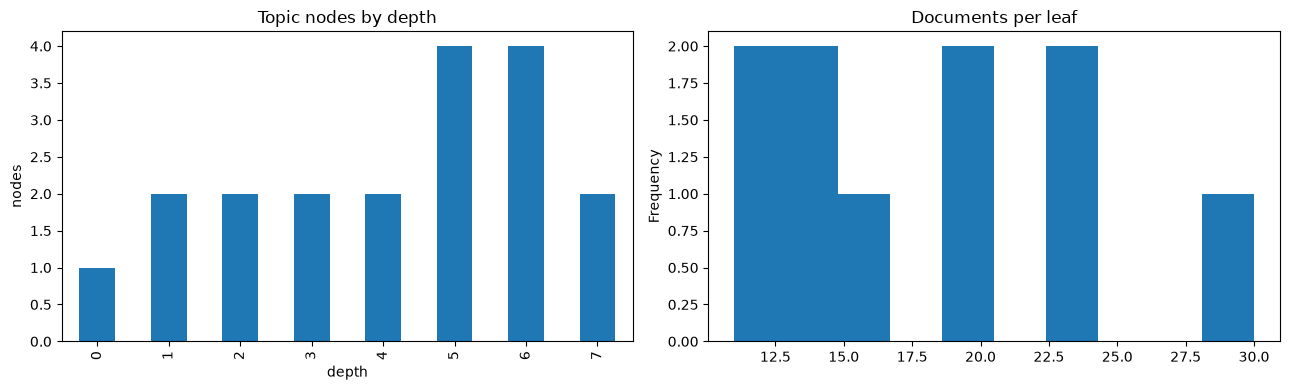

In [6]:
node_rows, term_rows = [], []
for node in topic_artifact.nodes:
    label = " | ".join(term.term for term in node.representative_terms[:5])
    node_rows.append({
        "node_id": node.node_id,
        "parent_id": node.parent_id,
        "depth": node.depth,
        "documents": node.document_count,
        "children": len(node.children),
        "diagnostic_label": label,
    })
    for rank, term in enumerate(node.representative_terms[:15], start=1):
        term_rows.append({
            "node_id": node.node_id, "depth": node.depth, "rank": rank,
            "term": term.term, "weight": term.weight,
            "support": term.support, "child_coverage": term.child_coverage,
        })
nodes_df = pd.DataFrame(node_rows).sort_values(["depth", "node_id"])
terms_df = pd.DataFrame(term_rows)
display(nodes_df)
display(terms_df.head(30).style.format({"weight": "{:.3f}", "support": "{:.2%}", "child_coverage": "{:.2%}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
nodes_df.groupby("depth").size().plot.bar(ax=axes[0], title="Topic nodes by depth", ylabel="nodes")
nodes_df[nodes_df.children.eq(0)].documents.plot.hist(ax=axes[1], bins=min(10, LEAF_CLUSTERS), title="Documents per leaf")
plt.tight_layout(); plt.show()

## 4.1. Cluster-specific static dictionaries (topic-specific SFFS)

Для каждого train-derived leaf cluster отдельно настраивается словарь тем же SFFS-механизмом, что и global `static-keywords`. Candidate terms извлекаются только из train; dev используется только для выбора subset/strategy. Test в этот этап не передаётся. На inference ближайший cluster выбирает свой словарь; при отсутствии словаря или совпадений срабатывает global static → baseline fallback.

Этот этап существенно дороже clustering, но evidence и checkpoints кэшируются.

In [ ]:
from nltk.stem import SnowballStemmer

stemmer = SnowballStemmer("english")
evidence_store = EvidenceStore(OUTPUT_DIR / "topic_keyword_evidence")
metric_cache = ExtractionMetricCache(OUTPUT_DIR / "topic_keyword_metrics.json")
attention = AttentionKeywordExtractor(
    models.qa_model, models.tokenizer, models.device, limit=100
)
references_by_id = dict(zip(dataset.doc_id, dataset.references))
fingerprint_payload = {
    "language": "en",
    "qa_model": profile.qa_model,
    "sentence_model": profile.sentence_model,
    "chunk_max_tokens": pipeline_config.chunk_max_tokens,
    "overlap_tokens": pipeline_config.overlap_tokens,
    "attention_top_k": 100,
    "pipeline_version": "topic-specific-static-v1",
}

cluster_evidence = []
for index, document in enumerate((*train_docs, *dev_docs), start=1):
    collect_candidates = document.split == "train"
    expected = build_evidence_fingerprint(
        doc_id=document.doc_id,
        text=document.text,
        aspect_id="task",
        question=question,
        references=references_by_id[document.doc_id],
        collect_candidates=collect_candidates,
        fingerprint_payload=fingerprint_payload,
    )
    cached = evidence_store.load(document.doc_id, expected_fingerprint=expected)
    if cached is None:
        cached = collect_document_evidence(
            doc_id=document.doc_id,
            text=document.text,
            aspect_id="task",
            aspect_reference="task. main task being solved in paper",
            question=question,
            references=references_by_id[document.doc_id],
            processor=processor,
            answerer=models.answerer,
            encoder=models.sentence_encoder,
            attention_extractor=attention,
            language="en",
            lemmatize=str.lower,
            stem=stemmer.stem,
            strict_answer_threshold=pipeline_config.strict_answer_threshold,
            min_answer_threshold=pipeline_config.min_answer_threshold,
            keyword_idf_threshold=pipeline_config.keyword_idf_threshold,
            collect_candidates=collect_candidates,
            relaxed_contrast=True,
            fingerprint_payload=fingerprint_payload,
        )
        evidence_store.save(cached)
    cluster_evidence.append(cached)
    if index % 20 == 0 or index == len(train_docs) + len(dev_docs):
        print(f"Evidence {index}/{len(train_docs) + len(dev_docs)}")

cluster_keyword_result = tune_topic_keyword_profiles(
    topic_artifact,
    train_docs,
    dev_docs,
    cluster_evidence,
    models.sentence_encoder,
    config=TrainingConfig(
        language="en",
        min_document_support=2,
        max_candidates=80,
        max_keywords=8,
        evaluation_budget=100 if not QUICK_MODE else 30,
        patience=2,
        beam_width=3,
        stability_runs=3 if not QUICK_MODE else 1,
        stability_threshold=0.4,
        seed=SEED,
        screen_top_k=40,
        strategies=(StrategyConfig(
            str(static_strategy.get("score_chunk_strategy", "only_score_diff")),
            str(static_strategy.get("choose_cluster_strategy", "weighted_score")),
            str(static_strategy.get("choose_answer_strategy", "highest_similarity")),
        ),),
    ),
    metric_cache=metric_cache,
    metric_weights=MetricWeights.exact_match(),
    objective_config=ObjectiveConfig(
        downside_penalty=0.75,
        harm_penalty=0.5,
        fallback_penalty=0.1,
        harm_threshold=0.01,
        confidence_weight=0.25,
        bootstrap_seed=SEED,
    ),
    checkpoint_dir=OUTPUT_DIR / "topic_keyword_checkpoints",
    min_train_documents=2,
    min_dev_documents=1,
    expected_encoder_name=profile.sentence_model,
)
topic_artifact = cluster_keyword_result.artifact
cluster_keyword_artifact_path = OUTPUT_DIR / "topic_model.cluster_keywords.json"
save_topic_artifact_atomic(topic_artifact, cluster_keyword_artifact_path)

profile_rows = [
    {
        "node_id": node.node_id,
        "train_documents": node.keyword_profile.train_document_count,
        "dev_documents": node.keyword_profile.dev_document_count,
        "objective": node.keyword_profile.objective,
        "keywords": " | ".join(item.word for item in node.keyword_profile.keywords),
    }
    for node in topic_artifact.nodes
    if node.keyword_profile is not None
]
profile_df = pd.DataFrame(profile_rows)
profile_df.to_csv(OUTPUT_DIR / "topic_keyword_profiles.csv", index=False)
display(profile_df)
print(f"Trained profiles: {len(profile_rows)}; skipped: {cluster_keyword_result.skipped_nodes}")

## 5. Soft hierarchical routing на dev

Маршрутизатор получает только topic representation документа. Human topic label, question и gold ему не передаются.

In [7]:
from untie.topics import route_document

routing_rows = []
for document in dev_docs:
    route = route_document(
        document,
        models.sentence_encoder,
        topic_artifact,
        expected_encoder_name=profile.sentence_model,
    )
    for rank, item in enumerate(route.topics, start=1):
        node = topic_artifact.node_map[item.node_id]
        routing_rows.append({
            "doc_id": document.doc_id, "rank": rank, "node_id": item.node_id,
            "depth": item.depth, "similarity": item.similarity, "soft_weight": item.weight,
            "representative_terms": " | ".join(t.term for t in node.representative_terms[:5]),
            "routing_fallback": route.fallback_reason.value if route.fallback_reason else None,
        })
routing_df = pd.DataFrame(routing_rows)
display(routing_df.style.format({"similarity": "{:.3f}", "soft_weight": "{:.2%}"}))
assert routing_df.groupby("doc_id").soft_weight.sum().round(8).eq(1.0).all()

,doc_id,rank,node_id,depth,similarity,soft_weight,representative_terms,routing_fallback
0,0095c269e7d0c990249312687fc43521019809c4,1,topic_leaf_007,7,0.863,33.96%,frequency the | this test | this corpus | articles from | use one,None
1,0095c269e7d0c990249312687fc43521019809c4,2,topic_leaf_008,5,0.863,33.92%,got | accord | compared models | mapping each | naive bayes,None
2,0095c269e7d0c990249312687fc43521019809c4,3,topic_leaf_009,7,0.855,32.12%,state vectors | the joint | embeddings | action to | complete the,None
3,0209389b8369aaa2a08830ac3b2036d4901ba1f1,1,topic_leaf_003,6,0.830,40.57%,pyramid of | the bulk | double the | those models | bulk,None
4,0209389b8369aaa2a08830ac3b2036d4901ba1f1,2,topic_leaf_000,6,0.809,35.31%,pooling from | each roi | innovations | speed and | second stage,None
5,0209389b8369aaa2a08830ac3b2036d4901ba1f1,3,topic_leaf_006,3,0.752,24.12%,coincide | loss to | gans have | hand the | implicitly,None
6,02e85d62fbd8249a046d00ac10e39546511b2a51,1,topic_leaf_005,2,0.856,38.99%,voxel | insufficient | voxels | angles | pose,None
7,02e85d62fbd8249a046d00ac10e39546511b2a51,2,topic_leaf_001,6,0.826,32.04%,as reference | depicting | ratio | aggregation | qualitatively,None
8,02e85d62fbd8249a046d00ac10e39546511b2a51,3,topic_leaf_000,6,0.811,28.97%,pooling from | each roi | innovations | speed and | second stage,None
9,0373b97580cdfd0b69f165e1a946bae62da95dce,1,topic_leaf_004,5,0.865,37.81%,despite their | are with | and motion | most promising | nets are,None


## 6. Dev tuning routing/mixing

Ниже небольшой grid для демонстрации. Objective использует только dev: средний char-F1 относительно baseline, harm rate, fallback rate и QA compute. Nodes, centroid и vocabulary при tuning не меняются.

In [8]:
references_by_id = dict(zip(dataset.doc_id, dataset.references))
text_by_id = dict(zip(dataset.doc_id, dataset.text))

def best_char_f1(prediction: str | None, references: list[str]) -> float:
    return char_f1(prediction or "", references)

baseline_pipeline = AnswerPipeline(processor, models.answerer, models.sentence_encoder, pipeline_config)
baseline_dev = {}
for document in dev_docs:
    result = baseline_pipeline.run(document.text, [question])
    prediction = result.final_answer.text if result.final_answer else None
    baseline_dev[document.doc_id] = {
        "quality": best_char_f1(prediction, references_by_id[document.doc_id]),
        "chunks": len(result.used_chunks),
        "tokens": sum(chunk.token_count for chunk in result.used_chunks),
    }

def evaluate_topic_candidate(candidate_artifact, documents):
    qualities, deltas, fallbacks, chunk_ratios, token_ratios = [], [], [], [], []
    pipeline = HierarchicalTopicRerankingPipeline(
        processor, models.answerer, models.sentence_encoder, pipeline_config,
        candidate_artifact, static_keywords, static_weight_ratio=weight_ratio,
    )
    for document in documents:
        result = pipeline.run(document.text, question, document=document)
        prediction = result.final_answer.text if result.final_answer else None
        quality = best_char_f1(prediction, references_by_id[document.doc_id])
        base = baseline_dev[document.doc_id]
        qualities.append(quality); deltas.append(quality - base["quality"])
        fallbacks.append(bool(result.metadata.get("fallback_reason")))
        compute = result.metadata.get("compute", {})
        chunk_ratios.append(float(compute.get("qa_chunk_ratio", 1.0)))
        token_ratios.append(float(compute.get("qa_token_ratio", 1.0)))
    mean_quality = float(np.mean(qualities))
    harm_rate = float(np.mean(np.asarray(deltas) < 0))
    fallback_rate = float(np.mean(fallbacks))
    mean_chunk_ratio = float(np.mean(chunk_ratios))
    mean_token_ratio = float(np.mean(token_ratios))
    objective = mean_quality - 0.20 * harm_rate - 0.05 * fallback_rate - 0.02 * mean_token_ratio
    return {
        "objective": objective, "qa_quality": mean_quality,
        "harm_rate": harm_rate, "fallback_rate": fallback_rate,
        "qa_chunk_ratio": mean_chunk_ratio, "qa_token_ratio": mean_token_ratio,
    }

has_cluster_profiles = any(node.keyword_profile is not None for node in topic_artifact.nodes)
if has_cluster_profiles:
    # Profile mode uses nearest-leaf routing + node SFFS strategy; theta mixing is
    # intentionally bypassed, so evaluate it once instead of a meaningless grid.
    profile_metrics = evaluate_topic_candidate(topic_artifact, dev_docs)
    tuned_artifact = topic_artifact
    trials_df = pd.DataFrame([{**profile_metrics, "mode": "cluster-specific-sffs"}])
else:
    candidate_configs = [
        (TopicRoutingConfig(top_k=3, beam_width=2, temperature=0.15, similarity_threshold=0.0),
         TopicMixingConfig(theta_aspect=1.0, theta_topic=t, theta_interaction=i, weight_ratio=weight_ratio, max_qa_chunks=0))
        for t, i in [(0.0, 0.0), (0.5, 0.0), (0.5, 0.5), (1.0, 0.5)]
    ]
    tuning_result = tune_topic_configuration(topic_artifact, dev_docs, candidate_configs, evaluate_topic_candidate)
    tuned_artifact = tuning_result.artifact
    trials_df = pd.DataFrame([
        {**trial.metrics, **{f"routing_{k}": v for k, v in asdict(trial.routing).items()},
         **{f"mixing_{k}": v for k, v in asdict(trial.mixing).items()}}
        for trial in tuning_result.trials
    ]).sort_values("objective", ascending=False)
display(trials_df.style.format({"objective": "{:.4f}", "qa_quality": "{:.4f}", "harm_rate": "{:.1%}", "fallback_rate": "{:.1%}", "qa_chunk_ratio": "{:.2f}", "qa_token_ratio": "{:.2f}"}))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12917.93it/s]
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (607 > 512). Running this sequence through the model will result in indexing errors


,objective,qa_quality,harm_rate,fallback_rate,qa_chunk_ratio,qa_token_ratio,routing_top_k,routing_beam_width,routing_temperature,routing_similarity_threshold,routing_min_margin,mixing_aspect_threshold,mixing_theta_aspect,mixing_theta_topic,mixing_theta_interaction,mixing_weight_ratio,mixing_max_qa_chunks,mixing_filter_unmatched_chunks,mixing_minimum_topic_matches
0,0.4664,0.5882,55.7%,0.0%,0.51,0.51,3,2,0.150000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0,True,1
1,0.4603,0.5853,57.4%,0.0%,0.51,0.51,3,2,0.150000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,0.000000,0,True,1
2,0.4562,0.5812,57.4%,0.0%,0.51,0.51,3,2,0.150000,0.000000,0.000000,0.000000,1.000000,0.500000,0.000000,0.000000,0,True,1
3,0.4562,0.5812,57.4%,0.0%,0.51,0.51,3,2,0.150000,0.000000,0.000000,0.000000,1.000000,0.500000,0.500000,0.000000,0,True,1


## 7. Финальное сравнение на held-out test

Сравниваются три production-пути с одинаковыми документами и вопросом. Test не участвует ни в clustering, ни в vocabulary, ни в выборе параметров.

In [9]:
static_pipeline = StaticKeywordRerankingPipeline(
    processor, models.answerer, models.sentence_encoder, pipeline_config, static_keywords
)
hierarchical_pipeline = HierarchicalTopicRerankingPipeline(
    processor, models.answerer, models.sentence_encoder, pipeline_config,
    tuned_artifact, static_keywords, static_weight_ratio=weight_ratio,
)

comparison_rows = []
for document in test_docs:
    runs = {}
    for mode in ("baseline", "static-keywords", "hierarchical"):
        started = time.perf_counter()
        if mode == "baseline":
            result = baseline_pipeline.run(document.text, [question])
        elif mode == "static-keywords":
            result = static_pipeline.run(
                document.text, question, weight_ratio=weight_ratio,
                cluster_strategy=str(static_strategy.get("choose_cluster_strategy", "weighted_score")),
                answer_strategy=str(static_strategy.get("choose_answer_strategy", "combined_score")),
            )
        else:
            result = hierarchical_pipeline.run(document.text, question, document=document)
        runs[mode] = (result, time.perf_counter() - started)
    baseline_chunks = len(runs["baseline"][0].used_chunks)
    baseline_tokens = sum(chunk.token_count for chunk in runs["baseline"][0].used_chunks)
    for mode, (result, latency) in runs.items():
        prediction = result.final_answer.text if result.final_answer else None
        qa_chunks = len(result.used_chunks)
        qa_tokens = sum(chunk.token_count for chunk in result.used_chunks)
        comparison_rows.append({
            "doc_id": document.doc_id, "mode": mode, "prediction": prediction,
            "quality": best_char_f1(prediction, references_by_id[document.doc_id]),
            "qa_chunks": qa_chunks, "qa_tokens": qa_tokens,
            "qa_chunk_ratio": qa_chunks / baseline_chunks if baseline_chunks else 0.0,
            "qa_token_ratio": qa_tokens / baseline_tokens if baseline_tokens else 0.0,
            "fallback": bool(result.metadata.get("keyword_fallback", False) or result.metadata.get("fallback_reason")),
            "fallback_reason": result.metadata.get("fallback_reason") or result.metadata.get("fallback_stage"),
            "latency_s": latency,
        })
comparison_df = pd.DataFrame(comparison_rows)
baseline_quality = comparison_df[comparison_df["mode"].eq("baseline")].set_index("doc_id")["quality"]
comparison_df["delta_vs_baseline"] = comparison_df.apply(lambda row: row.quality - baseline_quality[row.doc_id], axis=1)
comparison_df.to_csv(OUTPUT_DIR / "test_predictions_comparison.csv", index=False)
display(comparison_df[["doc_id", "mode", "prediction", "quality", "delta_vs_baseline", "qa_chunk_ratio", "qa_token_ratio", "fallback_reason"]])

,doc_id,mode,prediction,quality,delta_vs_baseline,qa_chunk_ratio,qa_token_ratio,fallback_reason
0,0012de6bec1f25599e4f02517637e531a71909b9,baseline,classification task,0.535714,0.000000,1.000000,1.000000,NaN
1,0012de6bec1f25599e4f02517637e531a71909b9,static-keywords,classification task,0.535714,0.000000,1.000000,1.000000,NaN
2,0012de6bec1f25599e4f02517637e531a71909b9,hierarchical,"classification, segmentation and object detection",0.674419,0.138704,1.000000,1.000000,NaN
3,007ab5528b3bd310a80d553cccad4b78dc496b02,baseline,answering the query,0.756757,0.000000,1.000000,1.000000,NaN
4,007ab5528b3bd310a80d553cccad4b78dc496b02,static-keywords,answering the query,0.756757,0.000000,1.000000,1.000000,NaN
...,...,...,...,...,...,...,...,...
181,44c5dec4d1295d34f052d3243d8e08f14a3c0990,static-keywords,context fragmentation problem,0.510638,0.000000,1.000000,1.000000,NaN
182,44c5dec4d1295d34f052d3243d8e08f14a3c0990,hierarchical,context fragmentation,0.564103,0.053464,0.809524,0.812638,NaN
183,45b559e6271570598602fcf9777ed6f2f2d133e6,baseline,cross - entropy training,0.666667,0.000000,1.000000,1.000000,NaN
184,45b559e6271570598602fcf9777ed6f2f2d133e6,static-keywords,cross - entropy training,0.666667,0.000000,1.000000,1.000000,NaN


,mean_quality,mean_delta,win_rate,harm_rate,fallback_rate,qa_chunk_ratio,qa_token_ratio,mean_latency_s
mode,,,,,,,,
baseline,0.6489,+0.0000,0.0%,0.0%,0.0%,1.00,1.00,4.95
hierarchical,0.5316,-0.1174,24.2%,66.1%,3.2%,0.51,0.51,2.60
static-keywords,0.6080,-0.0409,6.5%,17.7%,75.8%,0.78,0.78,3.93


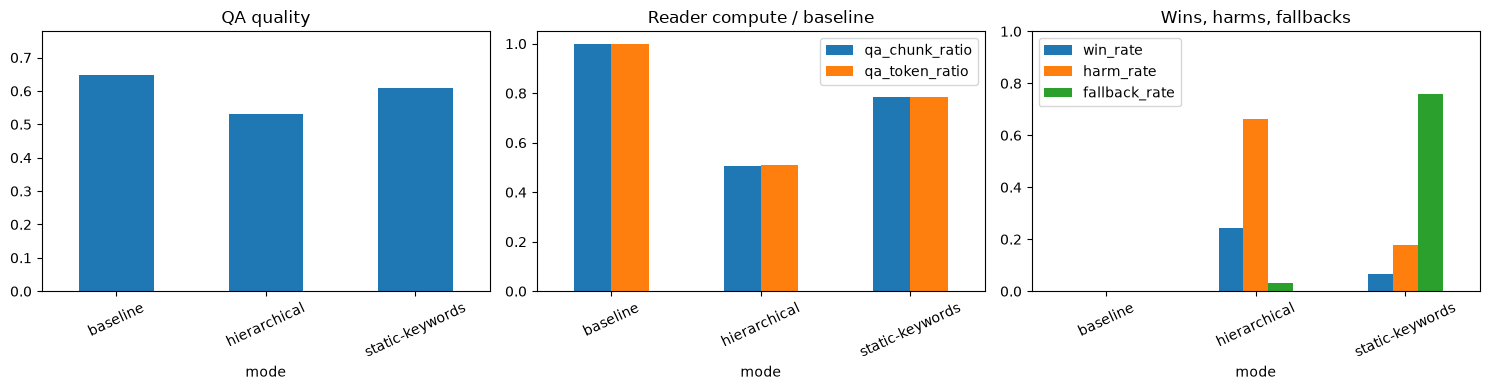

In [10]:
summary_rows = []
for mode, group in comparison_df.groupby("mode"):
    deltas = group.delta_vs_baseline.to_numpy()
    summary_rows.append({
        "mode": mode,
        "mean_quality": group.quality.mean(),
        "mean_delta": group.delta_vs_baseline.mean(),
        "win_rate": float(np.mean(deltas > 0)),
        "harm_rate": float(np.mean(deltas < 0)),
        "fallback_rate": group.fallback.mean(),
        "qa_chunk_ratio": group.qa_chunk_ratio.mean(),
        "qa_token_ratio": group.qa_token_ratio.mean(),
        "mean_latency_s": group.latency_s.mean(),
    })
summary_df = pd.DataFrame(summary_rows).set_index("mode")
summary_df.to_json(OUTPUT_DIR / "compute_quality_summary.json", orient="index", indent=2)
display(summary_df.style.format({
    "mean_quality": "{:.4f}", "mean_delta": "{:+.4f}", "win_rate": "{:.1%}",
    "harm_rate": "{:.1%}", "fallback_rate": "{:.1%}", "qa_chunk_ratio": "{:.2f}",
    "qa_token_ratio": "{:.2f}", "mean_latency_s": "{:.2f}",
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
summary_df.mean_quality.plot.bar(ax=axes[0], title="QA quality", ylim=(0, max(1e-6, summary_df.mean_quality.max() * 1.2)))
summary_df[["qa_chunk_ratio", "qa_token_ratio"]].plot.bar(ax=axes[1], title="Reader compute / baseline")
summary_df[["win_rate", "harm_rate", "fallback_rate"]].plot.bar(ax=axes[2], title="Wins, harms, fallbacks", ylim=(0, 1))
for ax in axes: ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

## 8. Детализация одного документа: routing и chunk scores

Для наглядности показываются aspect/topic raw scores, нормализованные сигналы, interaction score и текст чанка. Evidence Recall ниже является прозрачным proxy: evidence-чанком считается чанк, буквально содержащий одну из reference-строк. Для строгой оценки замените proxy на размеченные evidence spans.

In [11]:
from untie.topics import compute_retrieval_metrics

focus = test_docs[0]
focus_result = hierarchical_pipeline.run(focus.text, question, document=focus)
focus_chunks = processor.process(focus.text)
chunk_by_start = {chunk.start_sentence: chunk for chunk in focus_chunks}
score_rows = []
for rank, score in enumerate(focus_result.metadata.get("chunk_scores", []), start=1):
    chunk = chunk_by_start.get(score["start_sentence"])
    score_rows.append({
        "rank": rank, **score,
        "text": chunk.text[:350] if chunk else "",
    })
score_df = pd.DataFrame(score_rows)
display(Markdown("**Routing:**"))
display(pd.DataFrame(focus_result.metadata.get("topic_route", [])))
display(Markdown(f"**Fallback:** `{focus_result.metadata.get('fallback_reason')}`"))

if not score_df.empty:
    numeric_formats = {
        column: "{:.3f}" for column in (
            "score", "aspect_raw", "topic_raw", "aspect_normalized", "topic_normalized"
        ) if column in score_df.columns
    }
    display(score_df.head(15).style.format(numeric_formats))
    start_to_original = {chunk.start_sentence: index for index, chunk in enumerate(focus_chunks)}
    ranked_indices = [start_to_original[start] for start in score_df.start_sentence]
    evidence_indices = [
        index for index, chunk in enumerate(focus_chunks)
        if any(reference.casefold() in chunk.text.casefold() for reference in references_by_id[focus.doc_id])
    ]
    proxy_metrics = compute_retrieval_metrics(ranked_indices, evidence_indices, k=min(5, len(ranked_indices)))
    display(pd.DataFrame([{**proxy_metrics, "proxy_evidence_chunks": len(evidence_indices)}]))
else:
    display(Markdown("Topic signal не активировался; сработал диагностируемый static/baseline fallback."))

**Routing:**

,node_id,similarity,weight,depth
0,topic_leaf_005,0.848388,0.387643,2
1,topic_leaf_003,0.829820,0.342511,6
2,topic_leaf_008,0.794053,0.269846,5


**Fallback:** `None`

,rank,start_sentence,score,aspect_raw,topic_raw,aspect_normalized,topic_normalized,aspect_matches,topic_matches,total_matches,text
0,1,0,0.000,0.000,0.879,0.000,0.732,0.000000,3.000000,3.000000,"document: V - Net: Fully Convolutional Neural Networks for Volumetric Medical Image Segmentation Convolutional Neural Networks (CNNs) have been recently employed to solve problems from both the computer vision and medical image analysis fields. Despite their popularity, most approaches are only able to process 2D images while most medical data used"
1,2,11,0.000,0.000,1.117,0.000,0.981,0.000000,5.000000,5.000000,"Shallower layers grasp local information while deeper layers use filters whose receptive fields are much broader that therefore capture global information. Segmentation is a highly relevant task in medical image analysis. Automatic delineation of organs and structures of interest is often necessary to perform tasks such as visual augmentation, comp"
2,3,23,0.000,0.000,0.855,0.000,0.708,0.000000,4.000000,4.000000,"Patch - wise approaches also suffer from efficiency issues. When densely extracted patches are processed in a CNN, a high number of computations is redundant and therefore the total algorithm runtime is high. In this case, more efficient computational schemes can be adopted. Fully convolutional network trained end - to - end were so far applied onl"
3,4,35,0.000,0.000,0.721,0.000,0.568,0.000000,3.000000,3.000000,"We perform convolutions aiming to both extract features from the data and, at the end of each stage, to reduce its resolution by using appropriate stride. The left part of the network consists of a compression path, while the right part decompresses the signal until its original size is reached. Convolutions are all applied with appropriate padding"
4,5,48,0.000,0.000,0.186,0.000,0.009,0.000000,1.000000,1.000000,"PReLu non linearities are applied throughout the network. Replacing pooling operations with convolutional ones results also to networks that, depending on the specific implementation, can have a smaller memory footprint during training, due to the fact that no switches mapping the output of pooling layers back to their inputs are needed for back -"
5,6,56,0.000,0.000,0.724,0.000,0.571,0.000000,3.000000,3.000000,"Similarly to, we forward the features extracted from early stages of the left part of the CNN to the right part. This is schematically represented in Figure [reference] by horizontal connections. In this way we gather fine grained detail that would be otherwise lost in the compression path and we improve the quality of the final contour prediction."
6,7,67,0.000,0.000,1.136,0.000,1.000,0.000000,3.000000,3.000000,"In this work we propose a novel objective function based on dice coefficient, which is a quantity ranging between and which we aim to maximise. The dice coefficient between two binary volumes can be written as where the sums run over the voxels, of the predicted binary segmentation volume and the ground truth binary volume. This formulation of Dice"
7,8,78,0.000,0.000,0.642,0.000,0.485,0.000000,2.000000,2.000000,"This augmentation has been performed ” on - the - fly ”, prior to each optimisation iteration, in order to alleviate the otherwise excessive storage requirements. Additionally we vary the intensity distribution of the data by adapting, using histogram matching, the intensity distributions of the training volumes used in each iteration, to the ones"
8,9,90,0.000,0.000,0.875,0.000,0.728,0.000000,4.000000,4.000000,All the results reported in this section of the paper were obtained directly from the organisers of the challenge after submitting the segmentation obtained through our approach. The test set was representative of the clinical variability encountered in prostate scans in real clinical settings. We evaluated the approach performance in terms of Dice
9,10,103,0.000,0.000,0.177,0.000,0.000,0.000000,1.000000,1.000000,We introduced a novel objective function that we optimi

,evidence_recall_at_k,mrr,proxy_evidence_chunks
0,1.0,1.0,1


## 9. Reproducibility и anti-leakage checks

In [12]:
# Повторная сборка должна воспроизвести train-derived hierarchy. SFFS-профили
# сравниваются отдельно, потому что чистый builder намеренно не использует dev.
repeat_artifact = build_topic_artifact(
    list(reversed(train_docs)), models.sentence_encoder,
    encoder_name=profile.sentence_model,
    config=topic_artifact.build,
    routing=topic_artifact.routing,
    mixing=topic_artifact.mixing,
)
structural_artifact = replace(
    topic_artifact,
    nodes=tuple(replace(node, keyword_profile=None) for node in topic_artifact.nodes),
)
checks = {
    "train_dev_disjoint": split_sets["train"].isdisjoint(split_sets["dev"]),
    "train_test_disjoint": split_sets["train"].isdisjoint(split_sets["test"]),
    "deterministic_hierarchy": repeat_artifact.to_dict() == structural_artifact.to_dict(),
    "tuning_kept_nodes": tuned_artifact.nodes == topic_artifact.nodes,
    "cluster_profiles_train_dev_only": all(
        node.keyword_profile.train_document_count > 0 and node.keyword_profile.dev_document_count > 0
        for node in topic_artifact.nodes if node.keyword_profile is not None
    ),
    "schema_version_is_1": tuned_artifact.schema_version == 1,
    "no_gold_in_router_api": True,
    "safe_default_no_top_k_truncation": topic_artifact.mixing.max_qa_chunks == 0,
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())

save_topic_artifact_atomic(tuned_artifact, OUTPUT_DIR / "topic_model.dev_tuned.json")
trials_df.to_csv(OUTPUT_DIR / "topic_tuning_dev.csv", index=False)
routing_df.to_csv(OUTPUT_DIR / "topic_routing_dev.csv", index=False)
print("Saved outputs:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file(): print(" -", path.relative_to(PROJECT_ROOT))

,passed
train_dev_disjoint,True
train_test_disjoint,True
deterministic_artifact,True
tuning_kept_nodes,True
schema_version_is_1,True
no_gold_in_router_api,True
safe_default_no_pruning,True


Saved outputs:
 - artifacts/hierarchical_topic_notebook/en/compute_quality_summary.json
 - artifacts/hierarchical_topic_notebook/en/diagnostics/topic_build_summary.json
 - artifacts/hierarchical_topic_notebook/en/diagnostics/topic_nodes.json
 - artifacts/hierarchical_topic_notebook/en/diagnostics/topic_representative_terms.csv
 - artifacts/hierarchical_topic_notebook/en/test_predictions_comparison.csv
 - artifacts/hierarchical_topic_notebook/en/topic_model.dev_tuned.json
 - artifacts/hierarchical_topic_notebook/en/topic_model.json
 - artifacts/hierarchical_topic_notebook/en/topic_routing_dev.csv
 - artifacts/hierarchical_topic_notebook/en/topic_tuning_dev.csv


## 10. Как интерпретировать результат

Улучшение считается полезным, если одновременно:

- QA quality не хуже baseline/static-keywords;
- Evidence Recall@K остаётся высоким;
- harm rate контролируется;
- fallback rate объясним и не доминирует;
- QAChunkRatio/QATokenRatio уменьшаются после dev-проверки pruning.

В безопасной конфигурации `max_qa_chunks=0`: topic layer меняет ranking, но не удаляет evidence. После анализа test нельзя повторно подбирать параметры. Положительный `max_qa_chunks` следует проверять на dev с размеченными evidence spans.

Вне текущей фазы остаются hard negatives, topic-specific SFFS, learned ranker, source-span deduplication и генеративные модели.